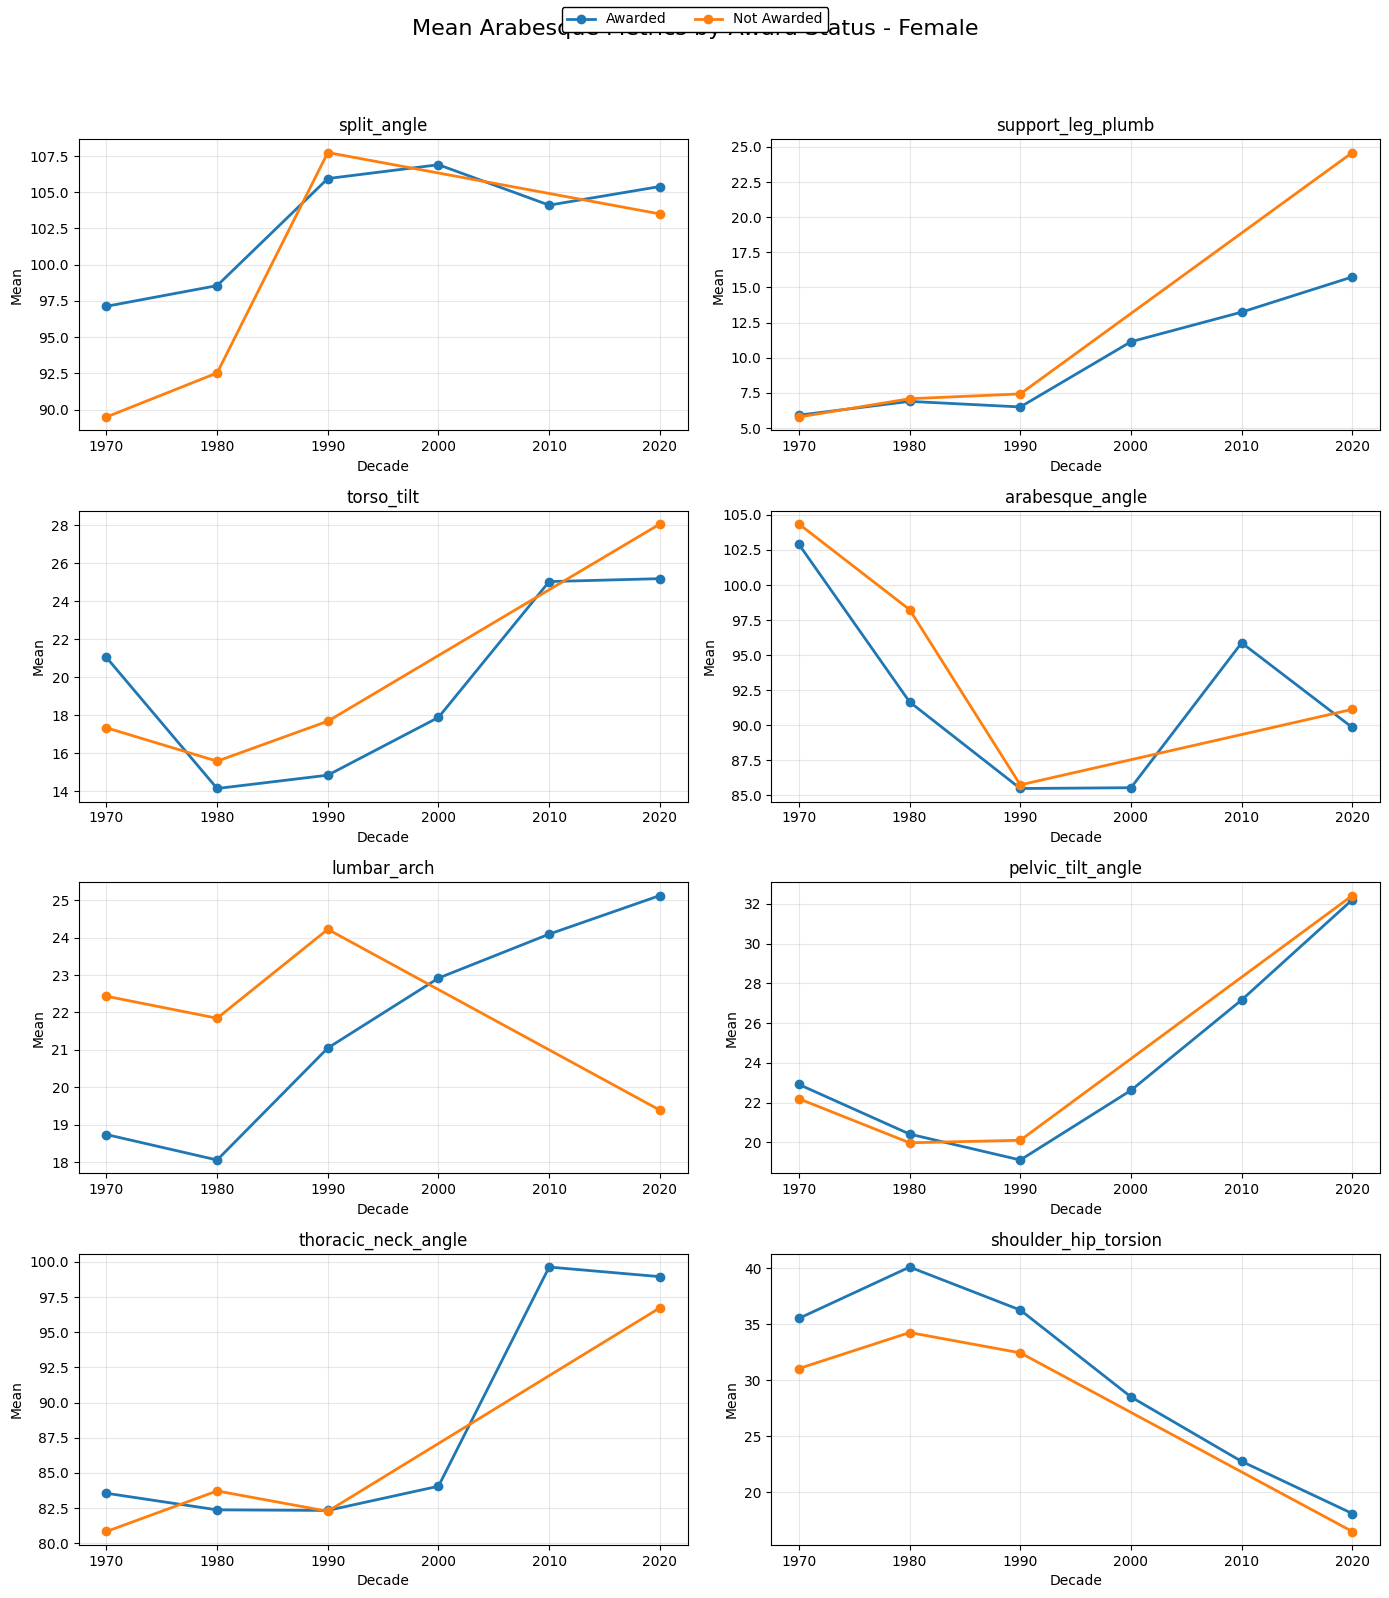

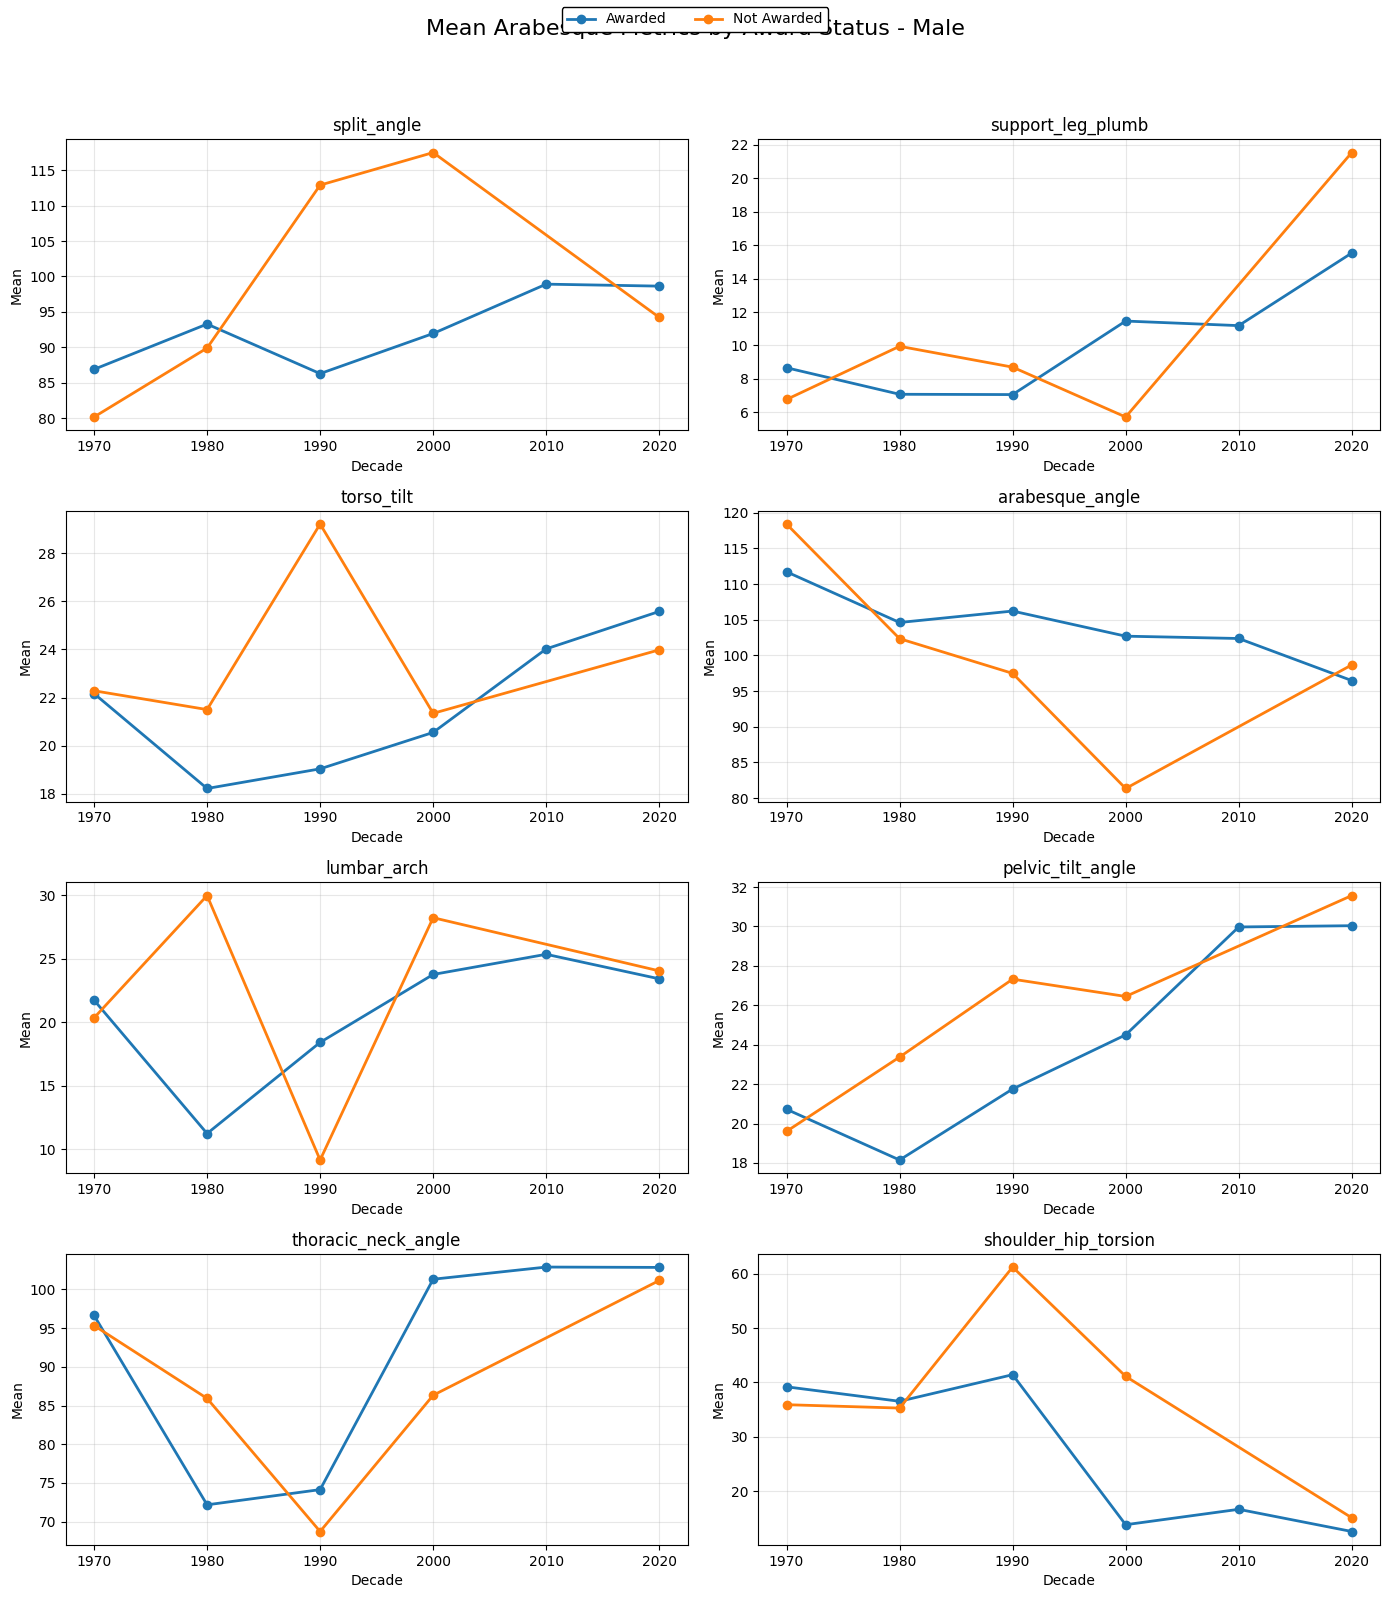

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Data/arabesque_cleaned_for_analysis_full.csv")

df["award_status"] = df["has_award"].map({
    1: "Awarded",
    0: "Not Awarded",
    "1": "Awarded",
    "0": "Not Awarded"
})

df["gender_label"] = df["real_gender"].map({
    "F": "Female",
    "M": "Male"
})

motion_metrics = [
    "split_angle",
    "support_leg_plumb",
    "torso_tilt",
    "arabesque_angle",
    "lumbar_arch",
    "pelvic_tilt_angle",
    "thoracic_neck_angle",
    "shoulder_hip_torsion"
]

award_gender_mean_by_decade = (
    df
    .dropna(subset=["award_status", "gender_label"])
    .groupby(["decade", "gender_label", "award_status"])[motion_metrics]
    .mean()
    .reset_index()
)

for gender in ["Female", "Male"]:
    fig, axes = plt.subplots(4, 2, figsize=(14, 16))
    axes = axes.flatten()

    gender_df = award_gender_mean_by_decade[
        award_gender_mean_by_decade["gender_label"] == gender
    ]

    for ax, metric in zip(axes, motion_metrics):
        for status in ["Awarded", "Not Awarded"]:
            sub = gender_df[
                gender_df["award_status"] == status
            ].sort_values("decade")

            ax.plot(
                sub["decade"],
                sub[metric],
                marker="o",
                linewidth=2,
                label=status
            )

        ax.set_title(metric)
        ax.set_xlabel("Decade")
        ax.set_ylabel("Mean")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()

    legend = fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=True
    )

    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("black")
    legend.get_frame().set_alpha(1)

    fig.suptitle(
        f"Mean Arabesque Metrics by Award Status - {gender}",
        fontsize=16,
        y=0.99
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()